# 0.0 IMPORTS

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn import preprocessing as pp
from category_encoders import TargetEncoder

## 0.1 Loading dataset

In [2]:
df_raw = pd.read_csv('../data/raw/train.csv')

# 1.0 DATA DESCRIPTION

## 1.1 Data Dimension

In [3]:
df_raw.columns = df_raw.columns.str.lower()
df1 = df_raw

In [4]:
print('Number of row : {}'.format(df1.shape[0]))
print('Number of columns : {}'.format(df1.shape[1]))

Number of row : 381109
Number of columns : 12


## 1.2 Data Types

In [5]:
df1.dtypes

id                        int64
gender                      str
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age                 str
vehicle_damage              str
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

## 1.3 Check NA

In [6]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

## 1.4 Data Descriptive

In [7]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64','datetime64[ns]'])

In [8]:
#central tendency - mediam, mean
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

#dispersion - std, min, max, range, skew, kurtose
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(np.min)).T
d3 = pd.DataFrame(num_attributes.apply(np.max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenar
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,0.000000,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,0.672539,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-21.595182,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-0.115266,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,0.167747,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-0.900008,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,0.003030,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906,3.298788


# 2.0 FEATURE ENGINEERING

In [9]:
df2 = df1.copy()

In [10]:
# vehicle age
df2['vehicle_age'] = df2['vehicle_age'].apply(lambda x:'over_2_years' if x== '> 2 Years' else 'between_1_2_years' if x =='1-2 Year' else 'below_1_year')
# vehicle damage
df2['vehicle_damage'] = df2['vehicle_damage'].apply(lambda x:1 if x =='Yes' else 0)

In [11]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,over_2_years,1,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,between_1_2_years,0,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,over_2_years,1,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,below_1_year,0,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,below_1_year,0,27496.0,152.0,39,0


# 3.0 DATA FILTERING

In [12]:
df3 = df2.copy()

# 4.0 EDA

In [13]:
df4 = df3.copy()

## 4.1 Analise univariada

In [14]:
df4.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='str')

### 4.1.1 age

<Axes: xlabel='response', ylabel='age'>

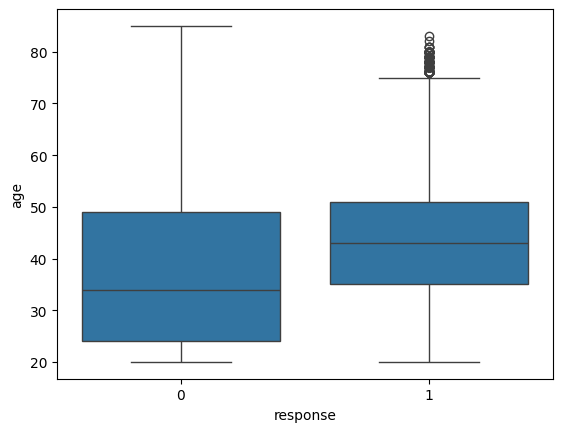

In [15]:
#'age'
sns.boxplot(x='response', y='age', data=df4)

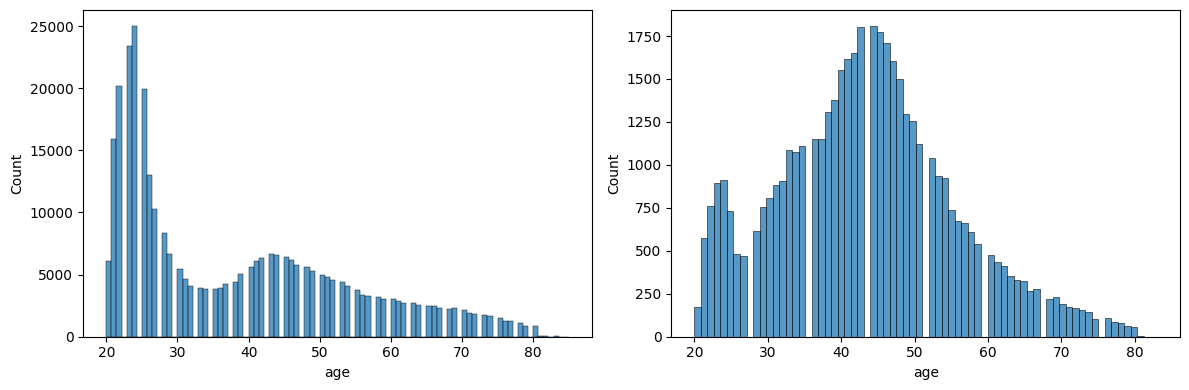

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = df4.loc[df4['response'] == 0, 'age']
sns.histplot(aux0, ax=ax1)

aux1 = df4.loc[df4['response'] == 1, 'age']
sns.histplot(aux1, ax=ax2)

plt.tight_layout()
plt.show()

### 4.1.1 Gender

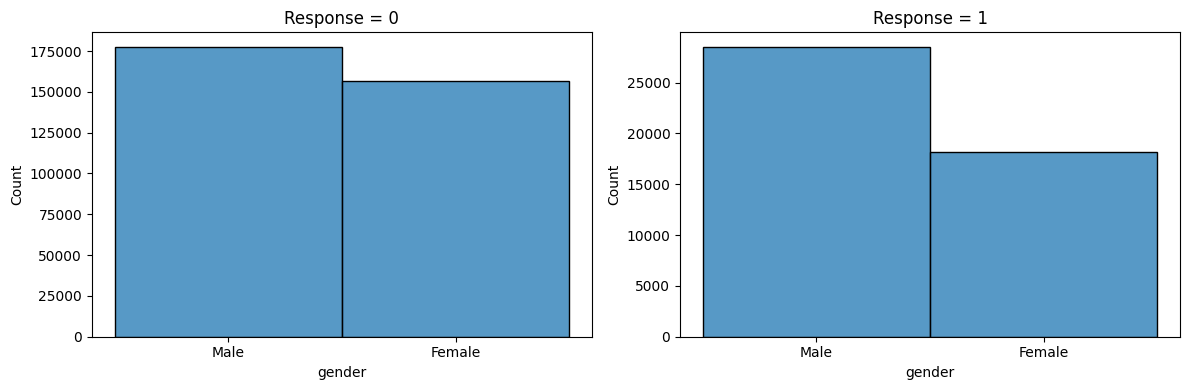

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = df4.loc[df4['response'] == 0, 'gender']
sns.histplot(aux0, ax=ax1)
ax1.set_title('Response = 0')

aux1 = df4.loc[df4['response'] == 1, 'gender']
sns.histplot(aux1, ax=ax2)
ax2.set_title('Response = 1')

plt.tight_layout()
plt.show()

### 4.1.3 annual_premium

<Axes: xlabel='response', ylabel='annual_premium'>

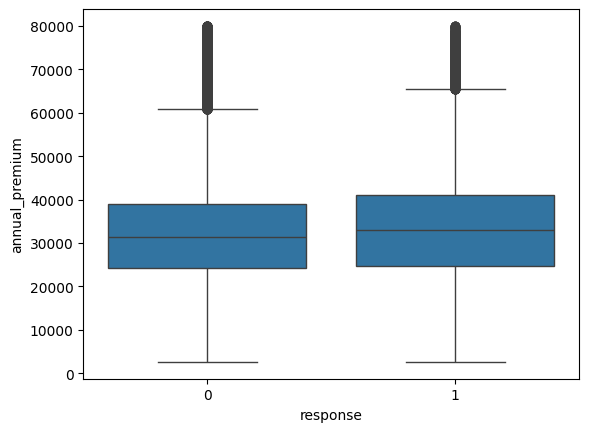

In [ ]:
aux2 = df4[df4['annual_premium'] < 80000]
sns.boxplot(x='response', y='annual_premium', data=aux2)

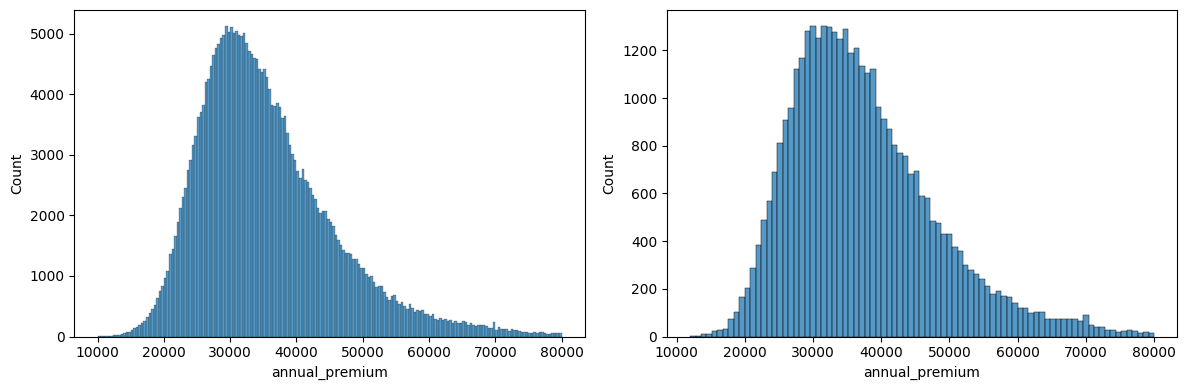

In [ ]:
aux2 = df4[(df4['annual_premium'] > 10000) & (df4['annual_premium'] < 80000)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux0 = aux2.loc[aux2['response'] == 0, 'annual_premium']
sns.histplot(aux0, ax=ax1)

aux1 = aux2.loc[aux2['response'] == 1, 'annual_premium']
sns.histplot(aux1, ax=ax2)

plt.tight_layout()
plt.show()

### 4.1.3 driving_license

<Axes: xlabel='response', ylabel='driving_license'>

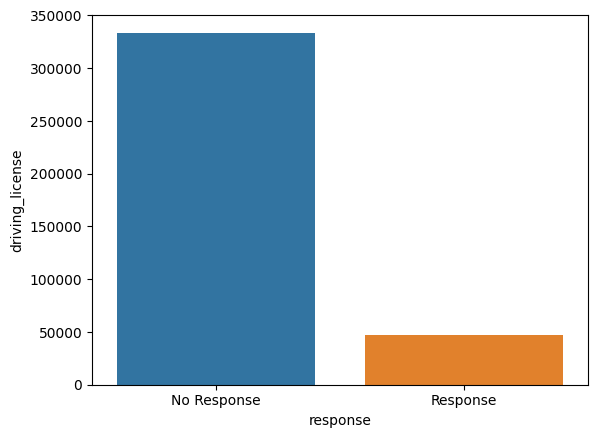

In [ ]:
aux = df4[['driving_license', 'response']].groupby('response').sum().reset_index()
aux['response'] = aux['response'].map({0: 'No Response', 1: 'Response'})
sns.barplot(x='response', y='driving_license', data=aux, hue='response')

In [ ]:
aux['driving_license_percent'] = aux['driving_license'] / aux['driving_license'].sum()
aux.head()

,response,driving_license,driving_license_percent
0,No Response,333628,0.877283
1,Response,46669,0.122717


### 4.1.4 region_code

<Axes: xlabel='region_code', ylabel='id'>

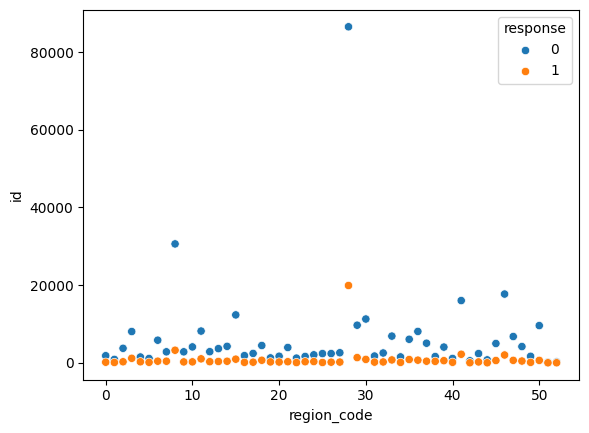

In [ ]:
aux4 = df4[['id','region_code','response']].groupby(['region_code','response']).count().reset_index()
sns.scatterplot(x='region_code', y='id', hue='response',data=aux4)

### 4.1.5 previously_insured

In [19]:
pd.crosstab(df4['previously_insured'], df4['response']).apply(lambda x: x/x.sum(), axis=1)

response,0,1
previously_insured,,
0,0.774546,0.225454
1,0.999095,0.000905


### 4.1.6 vehicle_age

In [25]:
df4[['vehicle_age','response']].value_counts(normalize=True).reset_index()

,vehicle_age,response,proportion
0,between_1_2_years,0,0.434285
1,below_1_year,0,0.413488
2,between_1_2_years,1,0.091328
3,over_2_years,0,0.029663
4,below_1_year,1,0.018897
5,over_2_years,1,0.012338


### 4.1.8 policy_sales_channel

<Axes: xlabel='response', ylabel='policy_sales_channel'>

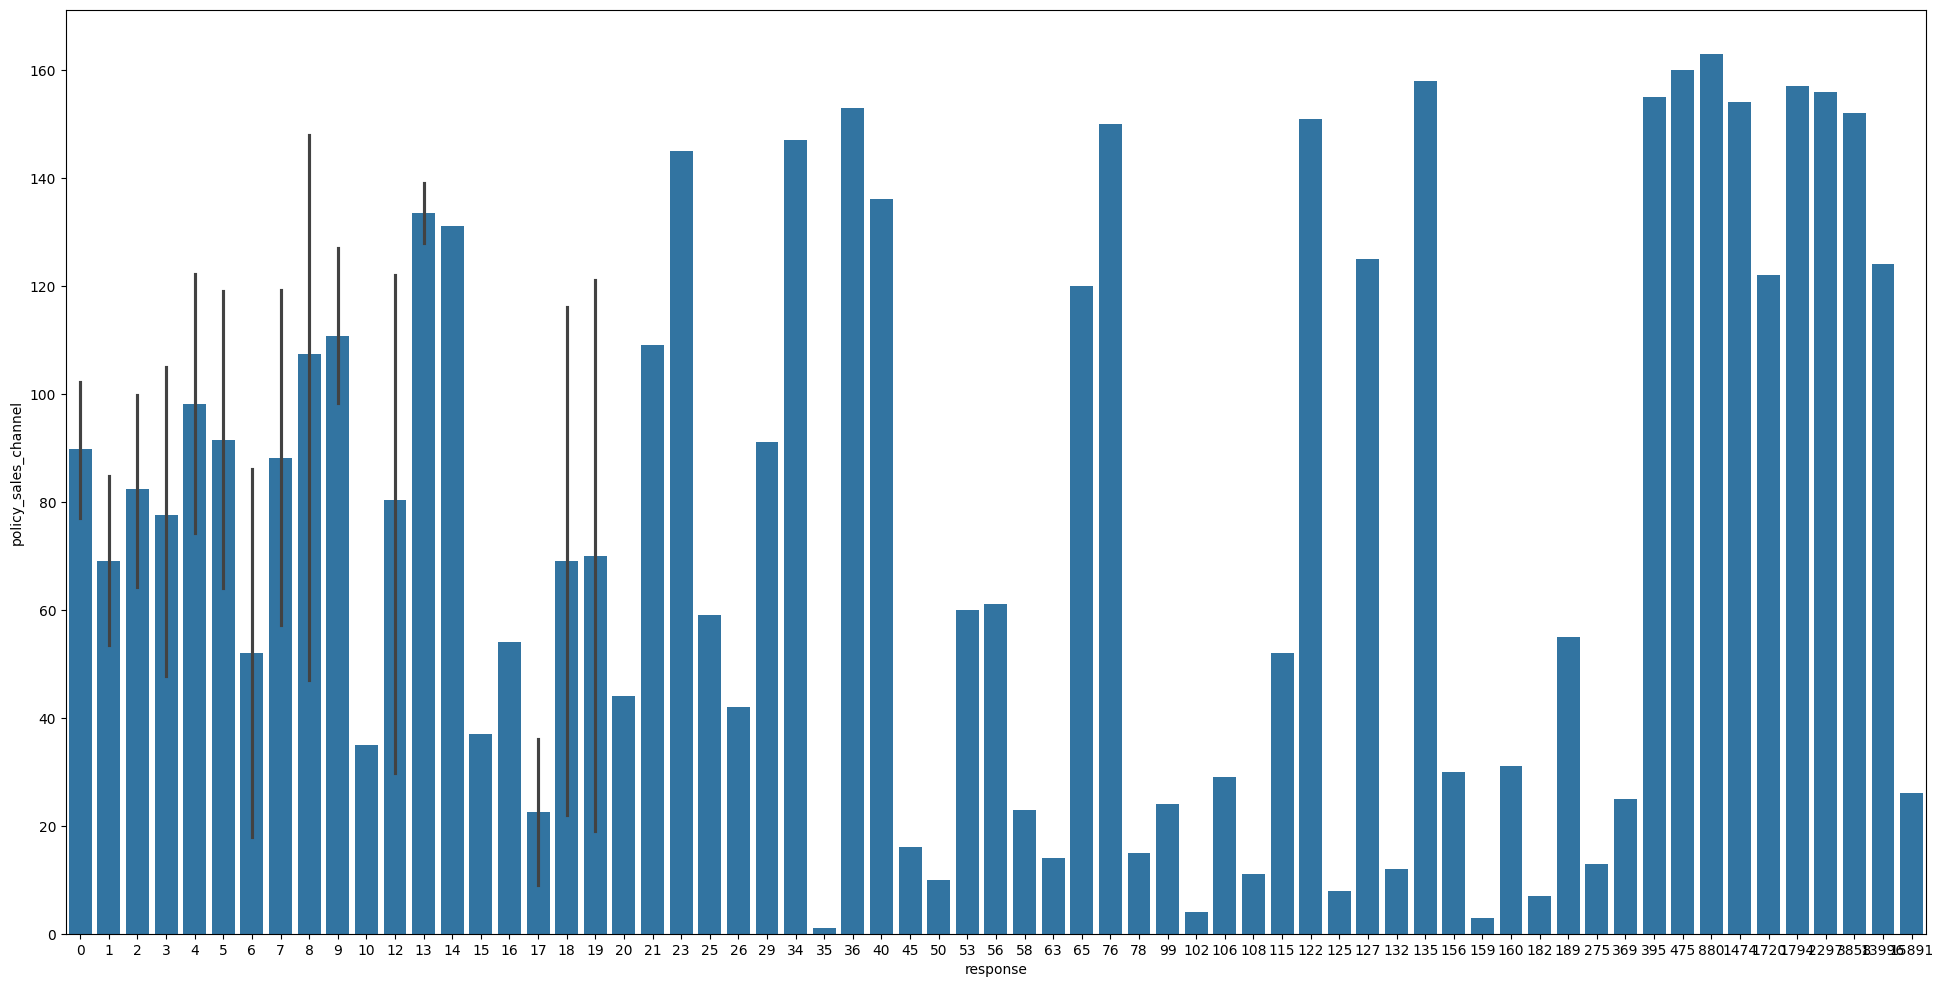

In [39]:
aux5 = df4[['policy_sales_channel','response']].groupby('policy_sales_channel').sum().reset_index()
plt.figure(figsize=(24,12))
sns.barplot(x='response', y='policy_sales_channel', data=aux5)

### 4.1.9 vintage

<Axes: xlabel='response', ylabel='vintage'>

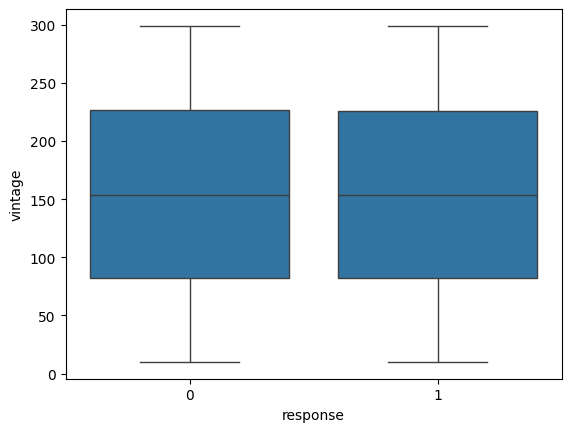

In [42]:
sns.boxplot(x='response', y='vintage', data=df4)

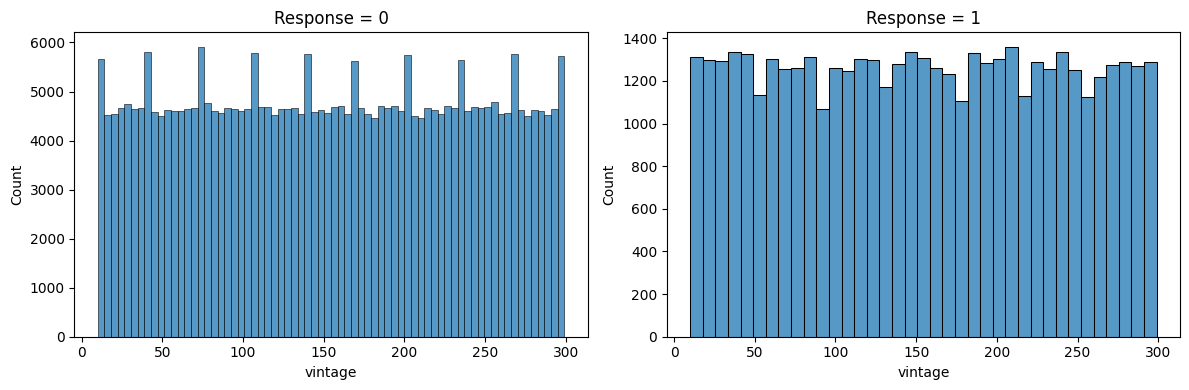

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

aux7 = df4.loc[df4['response'] == 0, 'vintage']
sns.histplot(aux7, ax=ax1)
ax1.set_title('Response = 0')

aux8 = df4.loc[df4['response'] == 1, 'vintage']
sns.histplot(aux8, ax=ax2)
ax2.set_title('Response = 1')

plt.tight_layout()
plt.show()

## 4.2 Analise bivariada

## 4.3 Analise multivariada

# 5.0 DATA PREPARATION

In [53]:
df5 = df4.copy()

## 5.1 Standardization

In [58]:
ss = pp.StandardScaler()
#annual_premium
df5['annual_premium'] = ss.fit_transform(df5[['annual_premium']].values)

## 5.2 Rescaling

In [59]:
#age (com o grafico histplot ficou evidente que precisa do rescaling)
mms_age = pp.MinMaxScaler()
df5['age'] = mms_age.fit_transform(df5[['age']].values)

#vintage
mms_vintage = pp.MinMaxScaler()
df5['vintage'] = mms_vintage.fit_transform(df5[['vintage']].values)

## 5.3 Encoder

In [ ]:
#region_code -   Frequency encoding / Target encoding / weighted target encoding
tg = TargetEncoder()
df5['region_code'] = tg.fit_transform(df5['region_code'], df5['response'])

#vehicle_age - One hot encoding / Order encoding / Frequency encoding
df5 = pd.get_dummies(df5, prefix='vehicle_age', columns=['vehicle_age'] )

#policy_sales_channel - Frequency encoding / Target encoding
fe_policy_sales_channel = df5.groupby('policy_sales_channel').size() / len(df5)
df5.loc[:, 'policy_sales_channel'] = df5['policy_sales_channel'].map(fe_policy_sales_channel)



# 6.0 FEATURE SELECTION

# 7.0 MACHINE LEARNING MODEL